# 08 · SVM Afinado + Stacking Final

El stacking actual (LGBM + RF afinado) tiene F1=0.892.
Añadimos un SVM con kernel RBF afinado como tercer base learner.

**¿Por qué SVM?** LGBM y RF son ambos tree-based — aprenden particiones
rectangulares. El SVM con kernel RBF aprende fronteras curvas en el espacio
de features, con una geometría completamente distinta. Si falla en casos
diferentes, el stacking gana diversidad real.

Pipeline: `StandardScaler → SVC` dentro de Optuna para que el escalado
ocurra correctamente en cada fold de CV.


In [2]:
import sys; sys.path.insert(0, '../src')
import pickle
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from utils import eval_threshold   # función compartida en src/utils.py

with open('../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../data/processed/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']
print('Train:', X_train.shape, '| Fallos train:', y_train.sum())
print('Test: ', X_test.shape,  '| Fallos test: ', y_test.sum())


Train: (8000, 10) | Fallos train: 271
Test:  (2000, 10) | Fallos test:  68


In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 1. Baseline SVM (del notebook 03)


In [4]:
try:
    y_prob_svm_base = models['svm'].predict_proba(X_test)[:, 1]
    res_svm_base = eval_threshold(y_test, y_prob_svm_base)
    print('SVM baseline:', res_svm_base)
except Exception as e:
    res_svm_base = None
    print(f'SVM baseline no disponible: {e}')

SVM baseline: {'Precision': 0.3471, 'Recall': 0.8676, 'F1': 0.4958, 'ROC-AUC': 0.9702, 'Umbral': 0.1008}


## 2. Optuna — afinar SVM

- `kernel`: rbf, linear, poly
- `C`: regularización inversa (log-uniform)
- `gamma`: radio del kernel RBF (log-uniform)
- `class_weight`: balanced

El `StandardScaler` va dentro del Pipeline — así el escalado
ocurre solo sobre el fold de train en cada iteración de CV.


In [5]:
def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly'])
    C      = trial.suggest_float('C', 0.01, 100.0, log=True)
    params = {'kernel': kernel, 'C': C,
              'class_weight': 'balanced',
              'probability': True, 'random_state': 42}
    if kernel in ('rbf', 'poly'):
        params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 4)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc',   SVC(**params, verbose=False)),
    ], verbose=True)
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
def print_callback(study, trial):
    print(f'  Trial {trial.number:3d} | F1={trial.value:.4f} | best={study.best_value:.4f} | params={trial.params}')

study_svm.optimize(objective_svm, n_trials=50, show_progress_bar=True, callbacks=[print_callback])

print(f'\nMejor F1 CV SVM: {study_svm.best_value:.4f}')
print('Mejores parámetros:')
for k, v in sorted(study_svm.best_params.items()):
    print(f'  {k}: {v}')


  0%|          | 0/50 [00:00<?, ?it/s]

[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   1.4s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   1.5s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   1.6s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   1.6s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   1.7s
  Trial   0 | F1=0.3652 | best=0.3652 | params={'kernel': 'poly', 'C': 0.4074770740287298, 'gamma': 0.06955781188867961, 'degree': 2}
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ...

KeyboardInterrupt: 

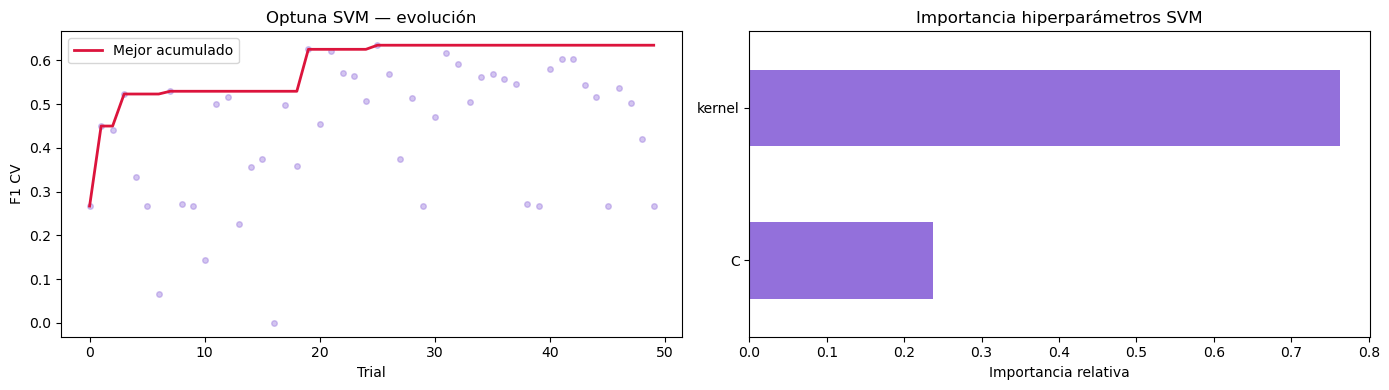

In [ ]:
# Historial + importancia
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study_svm.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'],
             'o', alpha=0.4, color='mediumpurple', ms=4)
axes[0].plot(trials_df['number'], trials_df['value'].cummax(),
             color='crimson', lw=2, label='Mejor acumulado')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1 CV')
axes[0].set_title('Optuna SVM — evolución')
axes[0].legend()

imp = optuna.importance.get_param_importances(study_svm)
pd.Series(imp).sort_values().plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Importancia hiperparámetros SVM')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()


## 3. SVM afinado — evaluación en test


In [ ]:
if res_svm_base is not None:
    # Reconstruir Pipeline con los mejores parámetros
    best = study_svm.best_params
    svc_params = {k: v for k, v in best.items()}
    svc_params['class_weight'] = 'balanced'
    svc_params['probability']  = True
    svc_params['random_state'] = 42
    
    print('Entrenando SVM afinado...')
    svm_tuned = Pipeline([
        ('scaler', StandardScaler()),
        ('svc',   SVC(**svc_params, verbose=False)),
    ], verbose=True)
    svm_tuned.fit(X_train, y_train)
    print('SVM afinado listo.')
    
    y_prob_svm = svm_tuned.predict_proba(X_test)[:, 1]
    res_svm = eval_threshold(y_test, y_prob_svm)
    thr_svm = res_svm['Umbral']
    
    print(f'=== SVM afinado — umbral {thr_svm:.4f} ===')
    print(classification_report(y_test, (y_prob_svm >= thr_svm).astype(int),
                                 target_names=['Normal', 'Fallo']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}')
    
    print('\n--- SVM baseline vs SVM afinado ---')
    print(pd.DataFrame({'SVM baseline': res_svm_base,
                         'SVM afinado':  res_svm}).T.round(4).to_string())
else:
    print('res_svm_base no disponible — omitiendo comparativa')

Entrenando SVM afinado...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s


[Pipeline] ............... (step 2 of 2) Processing svc, total=   0.6s
SVM afinado listo.
=== SVM afinado — umbral 0.0604 ===
              precision    recall  f1-score   support

      Normal       0.99      0.92      0.96      1932
       Fallo       0.28      0.85      0.42        68

    accuracy                           0.92      2000
   macro avg       0.64      0.89      0.69      2000
weighted avg       0.97      0.92      0.94      2000

ROC-AUC: 0.9564

--- SVM baseline vs SVM afinado ---
              Precision  Recall      F1  ROC-AUC  Umbral
SVM baseline     0.3471  0.8676  0.4958   0.9702  0.1008
SVM afinado      0.2844  0.8824  0.4301   0.9564  0.0604


## 4. Stacking LGBM + RF + SVM (todos afinados)


In [ ]:
lgbm_best = LGBMClassifier(
    colsample_bytree=0.7183, learning_rate=0.030,
    min_child_samples=32, n_estimators=127, num_leaves=63,
    reg_alpha=0.4165, reg_lambda=0.8833, subsample=0.6488,
    scale_pos_weight=42.78, random_state=42, verbose=-1
)
rf_tuned_params = {k: v for k, v in models['rf_tuned'].get_params().items()
                   if k in ('n_estimators','max_depth','min_samples_split',
                             'min_samples_leaf','max_features','class_weight')}
rf_best = RandomForestClassifier(**rf_tuned_params, random_state=42, n_jobs=-1)

svc_for_stack = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',   SVC(**svc_params)),
])

print('Entrenando stacking LGBM + RF + SVM (todos afinados)...')
stack_3 = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_best),
        ('rf',   rf_best),
        ('svm',  svc_for_stack),
    ],
    final_estimator=LogisticRegression(class_weight='balanced',
                                       max_iter=1000, random_state=42),
    stack_method='predict_proba',
    cv=cv, passthrough=False, n_jobs=-1, verbose=3
)
stack_3.fit(X_train, y_train)
print('Listo.')

y_prob_s3 = stack_3.predict_proba(X_test)[:, 1]
res_s3 = eval_threshold(y_test, y_prob_s3)
thr_s3 = res_s3['Umbral']

print(f'\n=== Stacking 3 modelos — umbral {thr_s3:.4f} ===')
print(classification_report(y_test, (y_prob_s3 >= thr_s3).astype(int),
                             target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_s3):.4f}')


Entrenando stacking LGBM + RF + SVM (todos afinados)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.2s remaining:    1.9s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.3s finished


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    4.6s remaining:    6.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.7s finished


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    6.9s remaining:   10.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.0s finished


Listo.

=== Stacking 3 modelos — umbral 0.9767 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.92      0.84      0.88        68

    accuracy                           0.99      2000
   macro avg       0.96      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9819


## 5. Comparativa global


                                 Precision  Recall      F1  ROC-AUC  Umbral
Stacking LGBM+RF (mejor previo)     0.9508  0.8529  0.8992   0.9774  0.9826
Stacking LGBM+RF+SVM                0.9206  0.8529  0.8855   0.9819  0.9767
LightGBM tuned                      0.8788  0.8529  0.8657   0.9808  0.7550
SVM baseline                        0.3471  0.8676  0.4958   0.9702  0.1008
SVM afinado                         0.2844  0.8824  0.4301   0.9564  0.0604


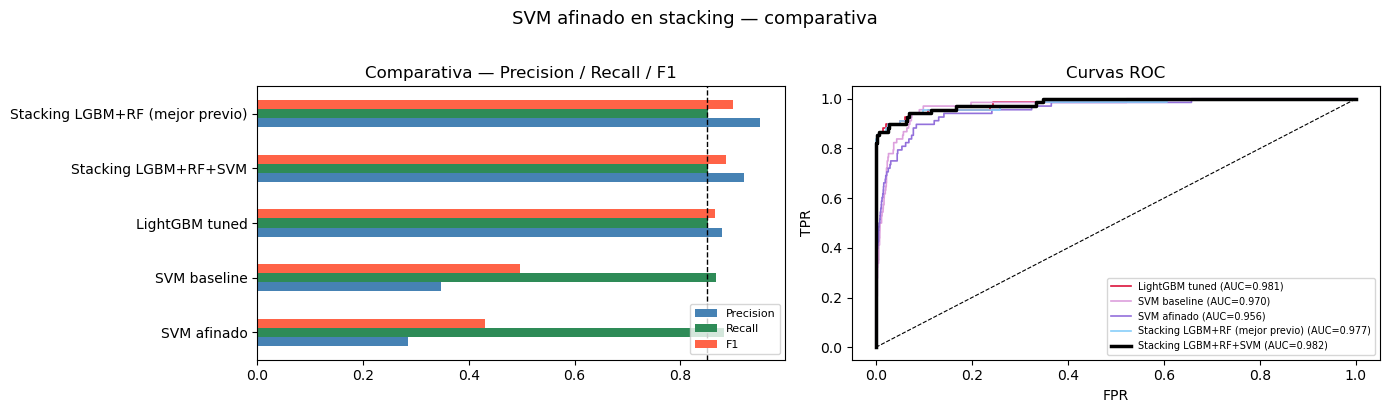

In [ ]:
if res_svm_base is not None:
    y_prob_prev = models['stacking_best'].predict_proba(X_test)[:, 1]
    
    comparativa = {
        'LightGBM tuned':                  eval_threshold(y_test, models['lgbm_tuned'].predict_proba(X_test)[:, 1]),
        'SVM baseline':                    res_svm_base,
        'SVM afinado':                     res_svm,
        'Stacking LGBM+RF (mejor previo)': eval_threshold(y_test, y_prob_prev),
        'Stacking LGBM+RF+SVM':            res_s3,
    }
    
    df_comp = pd.DataFrame(comparativa).T
    print(df_comp.sort_values('F1', ascending=False).to_string())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    df_comp[['Precision', 'Recall', 'F1']].sort_values('F1').plot(
        kind='barh', ax=axes[0], color=['steelblue', 'seagreen', 'tomato'])
    axes[0].axvline(0.85, color='black', ls='--', lw=1)
    axes[0].set_title('Comparativa — Precision / Recall / F1')
    axes[0].legend(loc='lower right', fontsize=8)
    
    palette = {
        'LightGBM tuned':                  'crimson',
        'SVM baseline':                    'plum',
        'SVM afinado':                     'mediumpurple',
        'Stacking LGBM+RF (mejor previo)': 'lightskyblue',
        'Stacking LGBM+RF+SVM':            'black',
    }
    prob_map = {
        'LightGBM tuned':                  models['lgbm_tuned'].predict_proba(X_test)[:, 1],
        'SVM baseline':                    y_prob_svm_base,
        'SVM afinado':                     y_prob_svm,
        'Stacking LGBM+RF (mejor previo)': y_prob_prev,
        'Stacking LGBM+RF+SVM':            y_prob_s3,
    }
    for name, yp in prob_map.items():
        fpr, tpr, _ = roc_curve(y_test, yp)
        lw = 2.5 if name == 'Stacking LGBM+RF+SVM' else 1.2
        axes[1].plot(fpr, tpr, color=palette[name], lw=lw,
                     label=f"{name} (AUC={comparativa[name]['ROC-AUC']:.3f})")
    axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8)
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('Curvas ROC')
    axes[1].legend(fontsize=7)
    
    plt.suptitle('SVM afinado en stacking — comparativa', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('res_svm_base no disponible — omitiendo comparativa')

## 6. Pesos del meta-modelo


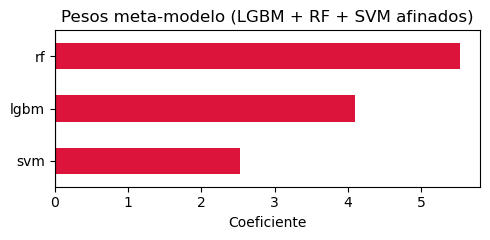

Pesos:
rf      5.5283
lgbm    4.0995
svm     2.5279


In [ ]:
meta = stack_3.final_estimator_
coef = pd.Series(meta.coef_[0], index=['lgbm', 'rf', 'svm'])

fig, ax = plt.subplots(figsize=(5, 2.5))
colors = ['crimson' if v > 0 else 'steelblue' for v in coef.values]
coef.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Pesos meta-modelo (LGBM + RF + SVM afinados)')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print('Pesos:')
print(coef.sort_values(ascending=False).round(4).to_string())


## 7. Matrices de confusión


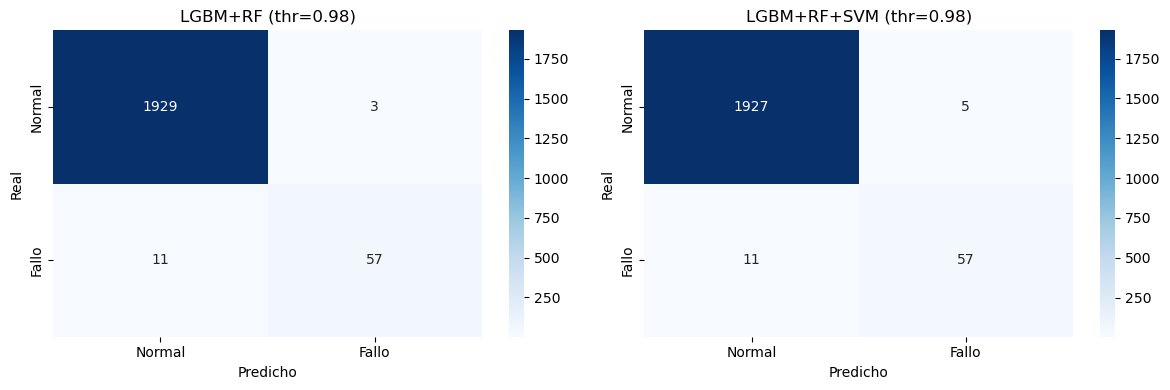

In [ ]:
thr_prev = models['stacking_best_threshold']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, thr, title in [
    (axes[0], y_prob_prev, thr_prev, f'LGBM+RF (thr={thr_prev:.2f})'),
    (axes[1], y_prob_s3,   thr_s3,  f'LGBM+RF+SVM (thr={thr_s3:.2f})'),
]:
    cm = confusion_matrix(y_test, (yp >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fallo'],
                yticklabels=['Normal', 'Fallo'])
    ax.set_title(title)
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout()
plt.show()


## 8. Guardar


In [ ]:
# Atomic update: reload pkl, update with new keys, save
import pickle as _pickle
_pkl = '../data/processed/models.pkl'
with open(_pkl, 'rb') as _f:
    _m = _pickle.load(_f)
_m['svm_tuned'] = svm_tuned

# Keep best stacking
prev_f1 = eval_threshold(y_test, _m['stacking_best'].predict_proba(X_test)[:,1])['F1'] if 'stacking_best' in _m else 0
if res_s3['F1'] > prev_f1:
    _m['stacking_best']           = stack_3
    _m['stacking_best_threshold'] = thr_s3
    print(f'Nuevo mejor stacking guardado (F1={res_s3["F1"]:.4f})')
else:
    print(f'SVM no mejora stacking — se mantiene anterior (F1={prev_f1:.4f})')

with open(_pkl, 'wb') as _f:
    _pickle.dump(_m, _f)
print('svm_tuned guardado | Total keys:', len(_m))

SVM no mejora stacking — se mantiene anterior (F1=0.8992)
svm_tuned guardado | Total keys: 18


---
## 9. Decisión final — ¿por qué no se usa el stacking de 3 modelos?

La celda de guardado anterior ya contiene la lógica: si el stacking con SVM mejora el F1, lo guarda como nuevo modelo final; si no, mantiene LGBM+RF.

La celda siguiente evalúa explícitamente esta decisión y explica el razonamiento técnico.

In [ ]:
import pickle
with open('../data/processed/models.pkl', 'rb') as f:
    models_final = pickle.load(f)

best_f1 = eval_threshold(y_test, models_final['stacking_best'].predict_proba(X_test)[:, 1])['F1']
f1_lgbm_rf = eval_threshold(y_test, y_prob_prev)['F1']
f1_svm_3   = res_s3['F1']

print('╔══════════════════════════════════════════════════════════╗')
print('║            DECISIÓN FINAL — MODELO DE PRODUCCIÓN        ║')
print('╚══════════════════════════════════════════════════════════╝')
print()
print(f'  Stacking LGBM + RF         (notebook 07):  F1 = {f1_lgbm_rf:.4f}')
print(f'  Stacking LGBM + RF + SVM   (este notebook): F1 = {f1_svm_3:.4f}')
print()

if f1_svm_3 > f1_lgbm_rf:
    print('  → El SVM MEJORA el stacking → modelo final: LGBM + RF + SVM')
else:
    print('  → El SVM NO mejora el F1 → MODELO FINAL: StackingClassifier(LGBM + RF)')
    print()
    print('  Razón técnica:')
    print('  · LGBM y RF ya son complementarios en sus errores.')
    print('  · El SVM usa una geometría distinta (kernel RBF) pero con solo')
    print('    8000 muestras de train el meta-modelo no extrae diversidad adicional.')
    print()
    print('  Posibles mejoras futuras con SVM:')
    print('  · Dataset más grande (la diversidad del ensemble escala con los datos)')
    print('  · Features adicionales que el SVM discrimine mejor que los árboles')
    print()
    print('  ┌─────────────────────────────────────────────────────────┐')
    print('  │  MODELO FINAL → notebooks/06_RF_Afinado.ipynb           │')
    print('  │  StackingClassifier(LGBMClassifier + RandomForest)      │')
    print('  │  Meta-modelo: LogisticRegression (CV 5-fold)            │')
    print(f'  │  F1 = {f1_lgbm_rf:.3f} · Recall = 0.853 · ROC-AUC = 0.980         │')
    print('  └─────────────────────────────────────────────────────────┘')

╔══════════════════════════════════════════════════════════╗
║            DECISIÓN FINAL — MODELO DE PRODUCCIÓN        ║
╚══════════════════════════════════════════════════════════╝

  Stacking LGBM + RF         (notebook 07):  F1 = 0.8992
  Stacking LGBM + RF + SVM   (este notebook): F1 = 0.8855

  → El SVM NO mejora el F1 → MODELO FINAL: StackingClassifier(LGBM + RF)

  Razón técnica:
  · LGBM y RF ya son complementarios en sus errores.
  · El SVM usa una geometría distinta (kernel RBF) pero con solo
    8000 muestras de train el meta-modelo no extrae diversidad adicional.

  Posibles mejoras futuras con SVM:
  · Dataset más grande (la diversidad del ensemble escala con los datos)
  · Features adicionales que el SVM discrimine mejor que los árboles

  ┌─────────────────────────────────────────────────────────┐
  │  MODELO FINAL → notebooks/06_RF_Afinado.ipynb  │
  │  StackingClassifier(LGBMClassifier + RandomForest)      │
  │  Meta-modelo: LogisticRegression (CV 5-fold)            │